# EDA (Explorarity Data Analysis)

**Loading Data from sql table**

In [34]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os


load_dotenv()
DB_USER, DB_PASS = os.getenv("DB_USER"), os.getenv("DB_PASS")
DB_NAME, DB_HOST, DB_PORT = os.getenv("DB_NAME"), os.getenv("DB_HOST"), os.getenv("DB_PORT")

conn_str = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)

df = pd.read_sql_table("ecommerce_churn", con=conn_str)
print(df)

      CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  \
0          50001      1     4.0         Mobile Phone         3   
1          50002      1     NaN                Phone         1   
2          50003      1     NaN                Phone         1   
3          50004      1     0.0                Phone         3   
4          50005      1     0.0                Phone         1   
...          ...    ...     ...                  ...       ...   
5625       55626      0    10.0             Computer         1   
5626       55627      0    13.0         Mobile Phone         1   
5627       55628      0     1.0         Mobile Phone         1   
5628       55629      0    23.0             Computer         3   
5629       55630      0     8.0         Mobile Phone         1   

      WarehouseToHome PreferredPaymentMode  Gender  HourSpendOnApp  \
0                 6.0           Debit Card  Female             3.0   
1                 8.0                  UPI    Male             3.0 

**Exploring Shape, dtypes and duplicate rows.**

In [35]:
print("## DF Shape is",df.shape)
print(df.dtypes)
print(df.duplicated().sum())

## DF Shape is (5630, 20)
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object
0


**Exploring missing values, and understanding missing data patterns**

                             Tenure  WarehouseToHome  HourSpendOnApp  \
Tenure                          264                0               0   
WarehouseToHome                   0              251               0   
HourSpendOnApp                    0                0             255   
OrderAmountHikeFromlastYear       0                0               0   
CouponUsed                        0                0               0   
OrderCount                        0                0               0   
DaySinceLastOrder                 0                0               0   

                             OrderAmountHikeFromlastYear  CouponUsed  \
Tenure                                                 0           0   
WarehouseToHome                                        0           0   
HourSpendOnApp                                         0           0   
OrderAmountHikeFromlastYear                          265           0   
CouponUsed                                             0       

<Figure size 1000x600 with 0 Axes>

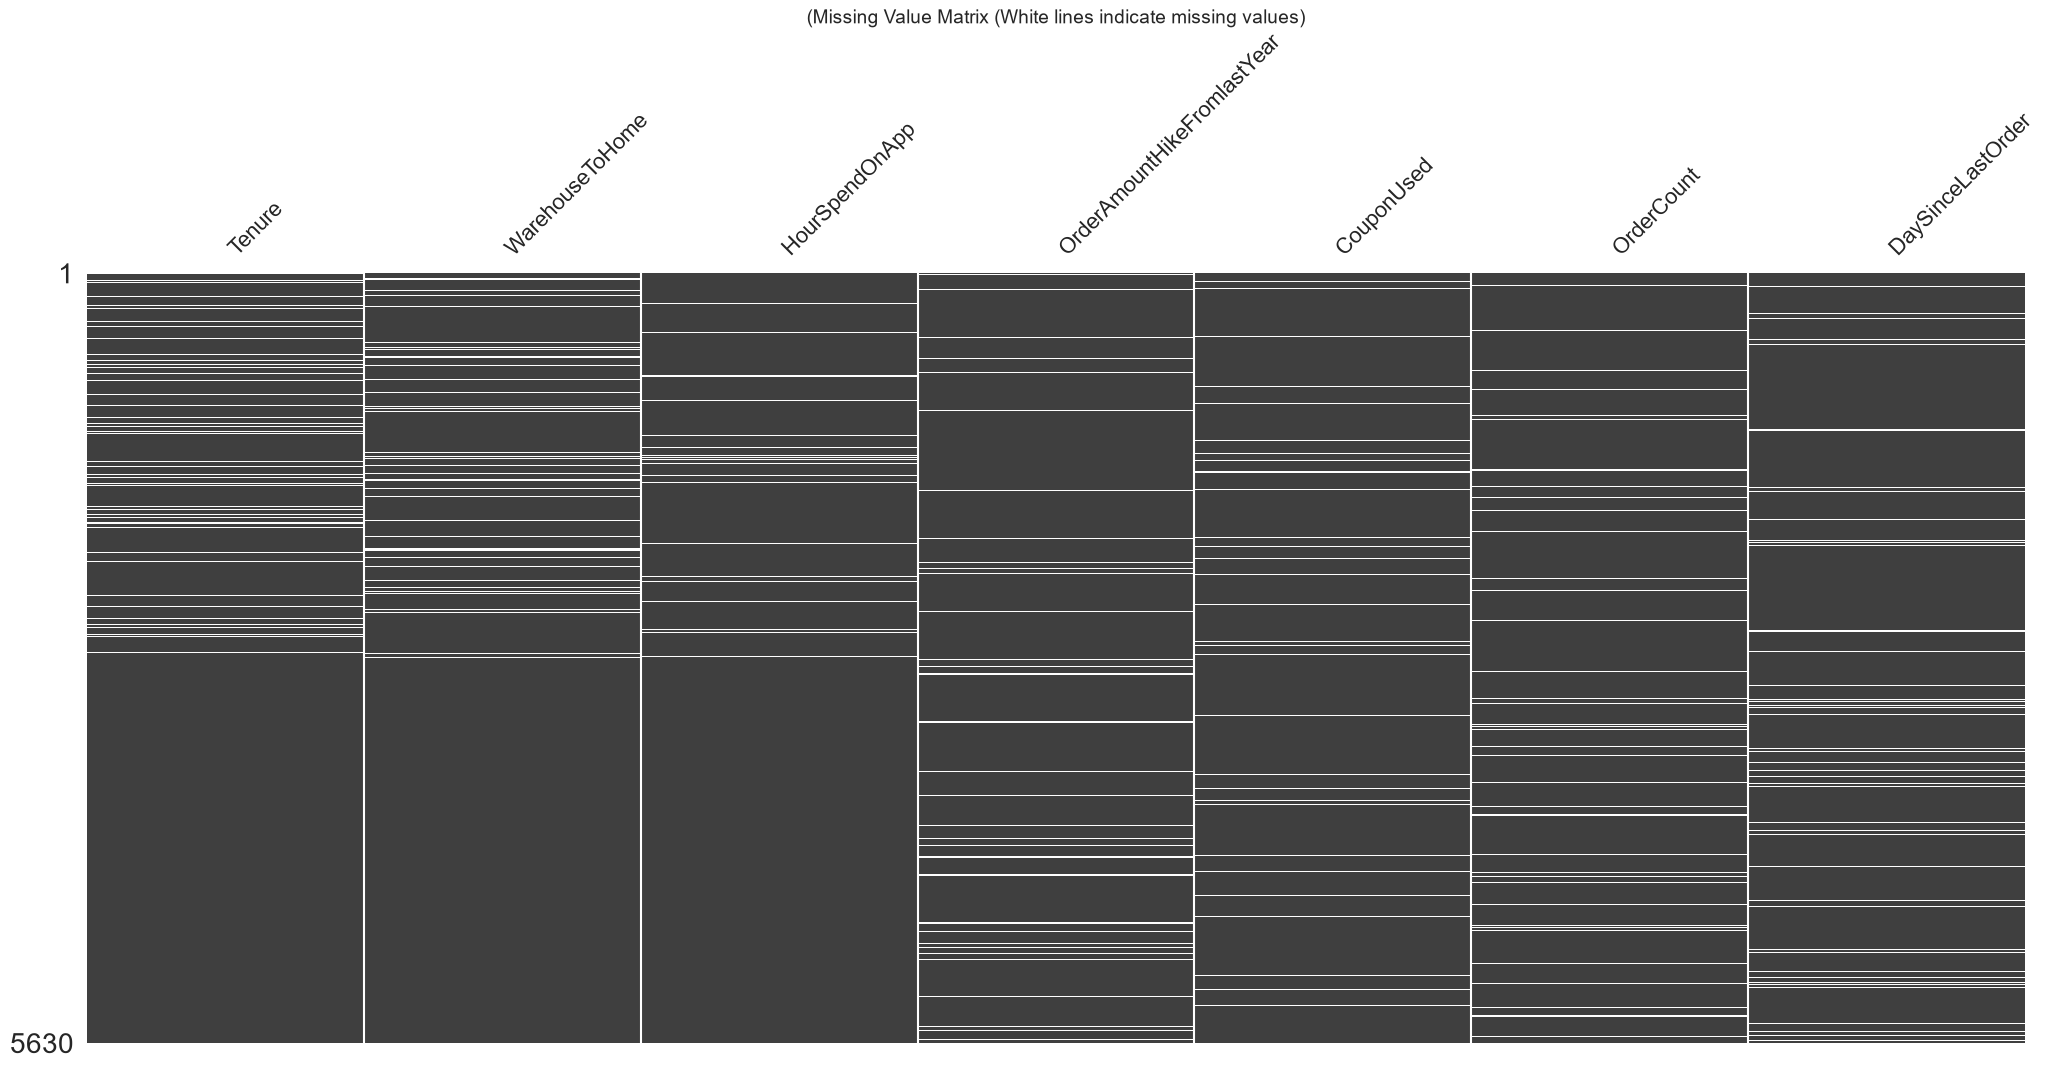

<Figure size 1600x1800 with 0 Axes>

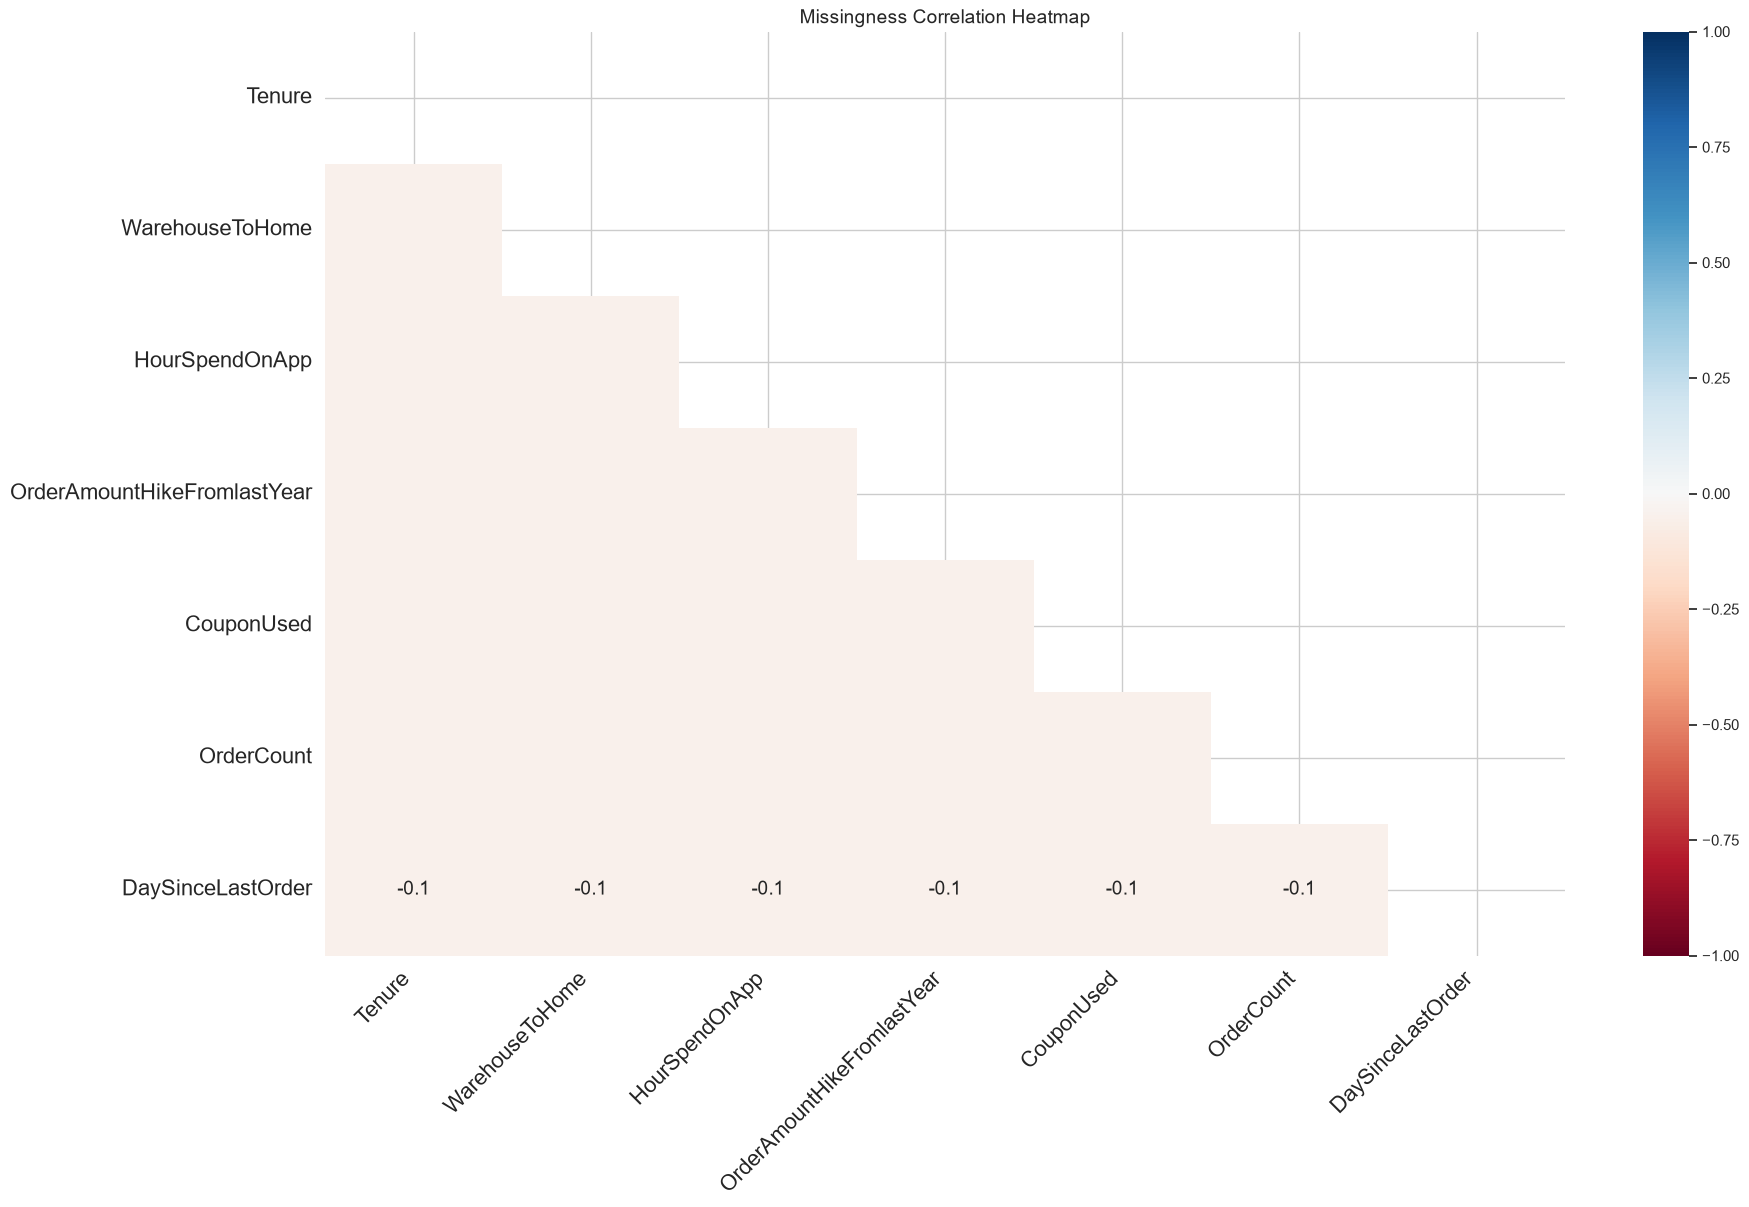

In [36]:
import missingno as msno
import matplotlib.pyplot as plt

df.isnull().sum()


missing_cols = ["Tenure","WarehouseToHome","HourSpendOnApp", "OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder"]
missing_per_row = df[missing_cols].isnull().sum(axis=1).value_counts()

null_matrix = df[missing_cols].isnull().astype(int)
co_occurrence_matrix = null_matrix.T.dot(null_matrix)
print(co_occurrence_matrix, '\n', "=" * 100)
print(null_matrix.corr())

# Plotting Null Matrix
plt.figure(figsize=(10, 6))
msno.matrix(df[missing_cols], sparkline=False)
plt.title("(Missing Value Matrix (White lines indicate missing values)", fontsize=14)
plt.show()

# Heatmap to see correlation between missing values
plt.figure(figsize=(16, 18))
msno.heatmap(df[missing_cols])
plt.title("Missingness Correlation Heatmap", fontsize=14)
plt.show()

# Interpreting Results and Selecting Imputation Strategy

Understanding missing data patterns is critical for selecting the appropriate strategy. Evaluating co-occurrence and correlation metrics determines whether univariate or multivariate imputation is required.

---

## Scenario A: High Co-occurrence (High Correlation / Shared Rows)

### 1. Observation

* The `missing_per_row` metric reveals multiple rows with 3, 4, or 5 missing values simultaneously.
* Visualization via `msno.heatmap()` shows strong positive correlation (near +1.0) between features such as `CouponUsed` and `OrderCount`.

### 2. Implication

Missingness is structurally connected across features. For instance, customers who have placed 0 orders inherently record `NaN` for `CouponUsed` and `DaySinceLastOrder`.

### 3. Imputation Strategy

* **Structural Missingness:** Apply logical rule-based filling (e.g., set `OrderCount`, `CouponUsed`, and `DaySinceLastOrder` to 0 for non-ordering users).
* **Systemic Missingness:** Apply multivariate imputation tools such as MICE (`IterativeImputer`) or `KNNImputer` to leverage relationships between features.

### Python Implementation

```python
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Step 1: Handle structural missingness with logical values
df["OrderCount"] = df["OrderCount"].fillna(0)
df.loc[df["OrderCount"] == 0, ["CouponUsed", "DaySinceLastOrder"]] = 0

# Step 2: Handle systemic missingness using MICE (IterativeImputer)
mice_imputer = IterativeImputer(random_state=42)
features_to_impute = ["Tenure", "CouponUsed", "DaySinceLastOrder"]
df[features_to_impute] = mice_imputer.fit_transform(df[features_to_impute])

```

---

## Scenario B: Low Co-occurrence / Independent Missingness

### 1. Observation

* The `missing_per_row` metric indicates that missingness is mostly isolated to 1 feature per row.
* Off-diagonal values in the `co_occurrence_matrix` remain near 0.

### 2. Implication

Missing values are scattered randomly across customer records without strong inter-feature dependency.

### 3. Imputation Strategy

* **Univariate Imputation:** Impute feature-by-feature independently.
* **Skewed Continuous Features:** Fill missing values using the column median (`Tenure`, `WarehouseToHome`, `DaySinceLastOrder`).
* **Discrete / Ordinal Features:** Fill missing values using the column median or mode (`HourSpendOnApp`, `OrderCount`).

### Python Implementation

```python
import pandas as pd

# Step 1: Univariate median imputation for skewed continuous features
continuous_cols = ["Tenure", "WarehouseToHome", "DaySinceLastOrder"]
for col in continuous_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Step 2: Univariate mode/median imputation for discrete or ordinal features
ordinal_cols = ["HourSpendOnApp", "OrderCount"]
for col in ordinal_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

```
---

**Overall churn rate — how imbalanced is it?**

In [37]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

**Univariate: distributions of Tenure, WarehouseToHome, SatisfactionScore, CashbackAmount.**

            Tenure  WarehouseToHome  SatisfactionScore  CashbackAmount
count  5366.000000      5379.000000        5630.000000     5630.000000
mean     10.189899        15.639896           3.066785      177.223030
std       8.557241         8.531475           1.380194       49.207036
min       0.000000         5.000000           1.000000        0.000000
25%       2.000000         9.000000           2.000000      145.770000
50%       9.000000        14.000000           3.000000      163.280000
75%      16.000000        20.000000           4.000000      196.392500
max      61.000000       127.000000           5.000000      324.990000
==================Skew=====================
Tenure               0.736513
WarehouseToHome      1.619154
SatisfactionScore   -0.142626
CashbackAmount       1.149846
dtype: float64
==================Missing Values=========================
Tenure               264
WarehouseToHome      251
SatisfactionScore      0
CashbackAmount         0
dtype: int64
===========

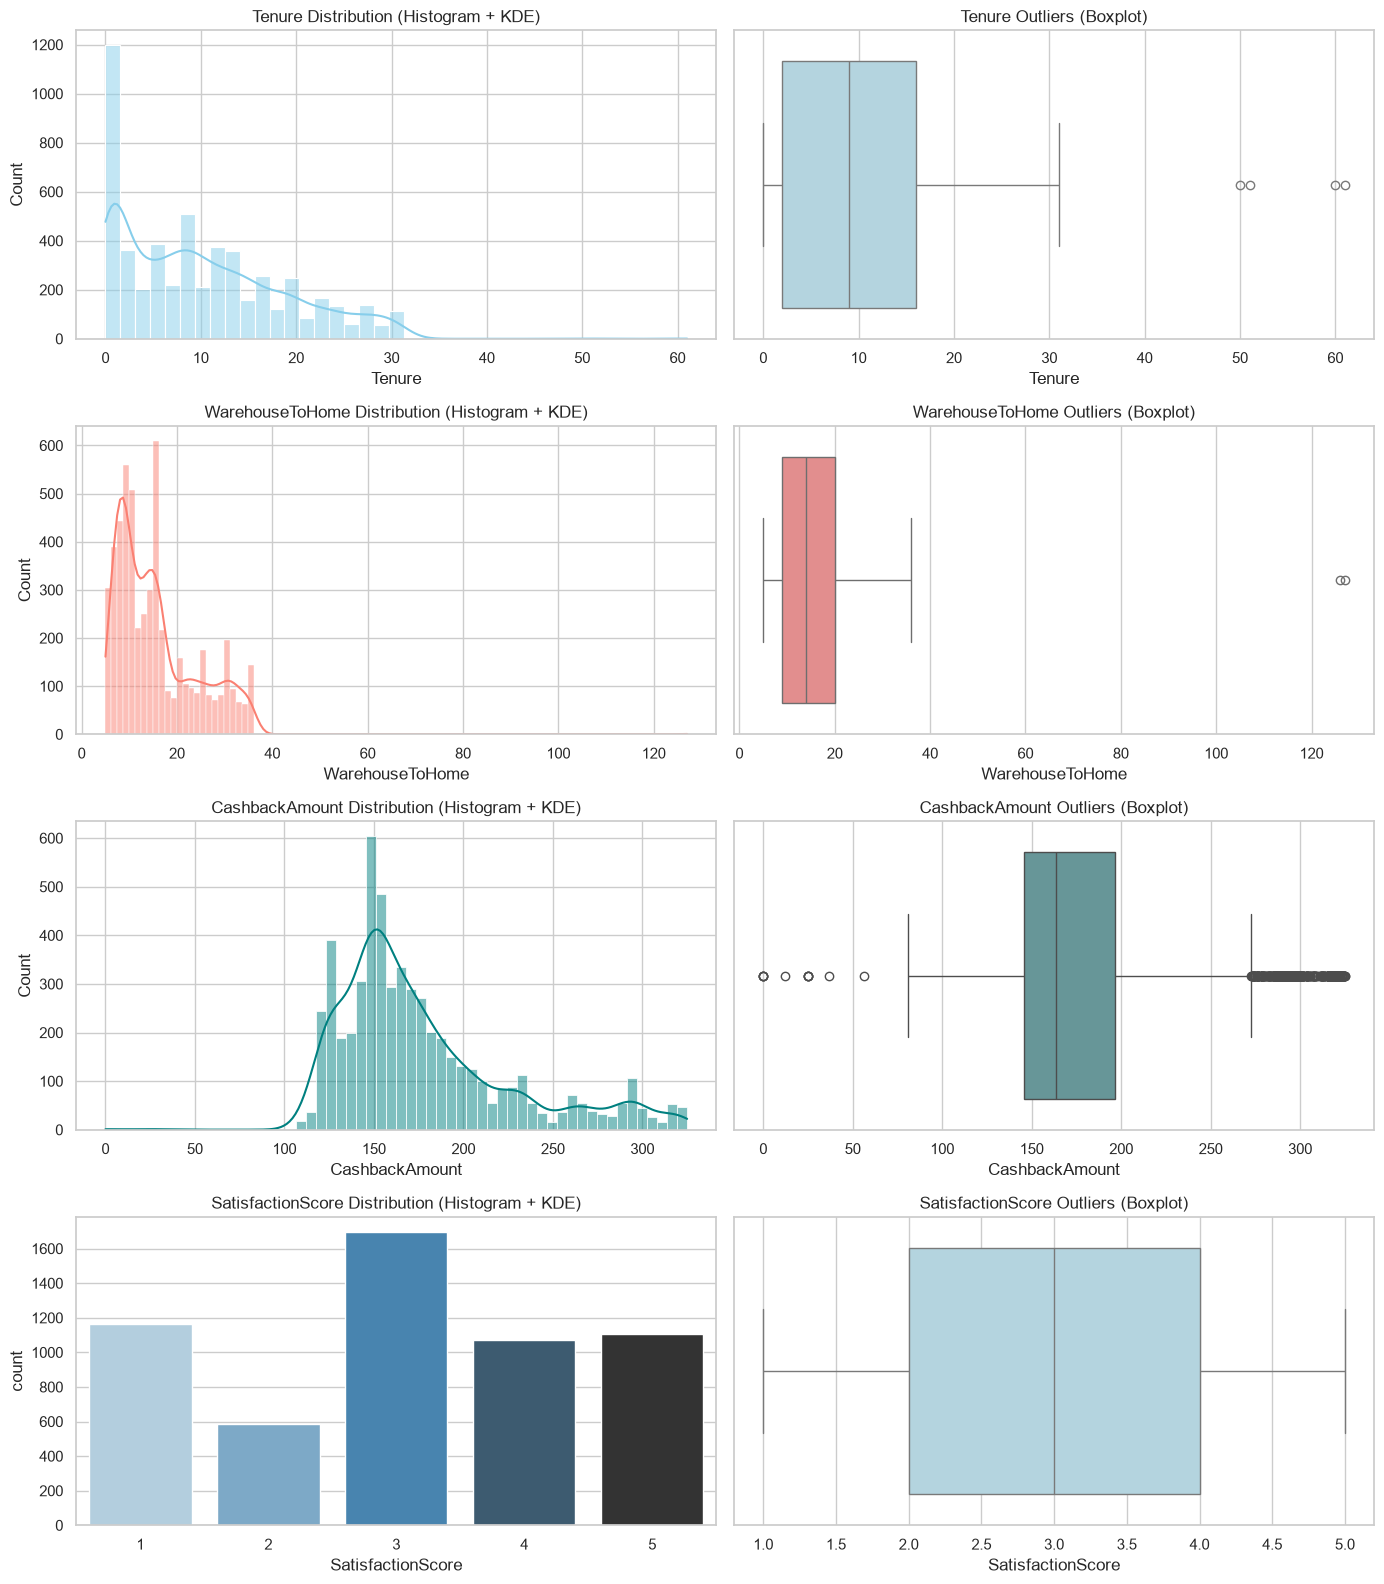

In [38]:
target_cols = ["Tenure", "WarehouseToHome", "SatisfactionScore", "CashbackAmount"]
print(df[target_cols].describe())

print("==================Skew=====================")
print(df[target_cols].skew())

print("==================Missing Values=========================")
print(df[target_cols].isnull().sum())

print("==================Plotting=======================================")
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

## 1 ---Tenure---
sns.histplot(df["Tenure"], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Tenure Distribution (Histogram + KDE)")

sns.boxplot(x=df["Tenure"], ax=axes[0, 1], color="lightblue")
axes[0, 1].set_title("Tenure Outliers (Boxplot)")

## 2 ---WarehouseToHome---
sns.histplot(df["WarehouseToHome"], kde=True, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("WarehouseToHome Distribution (Histogram + KDE)")

sns.boxplot(x=df["WarehouseToHome"], ax=axes[1, 1], color="lightcoral")
axes[1, 1].set_title("WarehouseToHome Outliers (Boxplot)")

## 3 ---CashbackAmount---
sns.histplot(df["CashbackAmount"], kde=True, ax=axes[2, 0], color="teal")
axes[2, 0].set_title("CashbackAmount Distribution (Histogram + KDE)")

sns.boxplot(x=df["CashbackAmount"], ax=axes[2, 1], color="cadetblue")
axes[2, 1].set_title("CashbackAmount Outliers (Boxplot)")

## 4 ---SatisfactionScore---
sns.countplot(x="SatisfactionScore", data=df, ax=axes[3, 0], palette="Blues_d", hue="SatisfactionScore", legend=False)
axes[3, 0].set_title("SatisfactionScore Distribution (Histogram + KDE)")

sns.boxplot(x=df["SatisfactionScore"], ax=axes[3, 1], color="lightblue")
axes[3, 1].set_title("SatisfactionScore Outliers (Boxplot)")

plt.tight_layout()
plt.show()

**Bivariate vs. churn: CityTier, PreferredLoginDevice, MaritalStatus, Complain, PreferredPaymentMode.**

In [39]:
print(df["PreferredLoginDevice"].value_counts())
print(df["PreferredPaymentMode"].value_counts())

df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({"CC": "Credit Card", "COD": "Cash on Delivery"})
df["PreferredPaymentMode"].value_counts()

target_cols = ["CityTier", "PreferredLoginDevice", "MaritalStatus", "Complain", "PreferredPaymentMode"]
for col in target_cols:
    summary = df.groupby(col)["Churn"].agg(
        Total_Customers = "count",
        Churned_Customers = "sum",
        Churned_Rate_Pct = lambda x: round(x.mean() * 100, 2)
    ).reset_index()
    
    print("\n")
    print(f"{"="*30} {col} vs Churn Bivariate {"="*30}")
    print(summary)
    

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64


============================== CityTier vs Churn Bivariate ==============================
   CityTier  Total_Customers  Churned_Customers  Churned_Rate_Pct
0         1             3666                532             14.51
1         2              242                 48             19.83
2         3             1722                368             21.37


============================== PreferredLoginDevice vs Churn Bivariate ==============================
  PreferredLoginDevice  Total_Customers  Churned_Customers  Churned_Rate_Pct
0             Computer             1634                324             19.83
1                Phone             3996               

0    14.511729
1    19.834711
2    21.370499
Name: Churned_Pct, dtype: float64
0    19.828641
1    15.615616
Name: Churned_Pct, dtype: float64
0    14.622642
1    11.520429
2    26.726058
Name: Churned_Pct, dtype: float64
0    10.928962
1    31.670823
Name: Churned_Pct, dtype: float64
0    24.902724
1    14.205186
2    15.384615
3    22.801303
4    17.391304
Name: Churned_Pct, dtype: float64


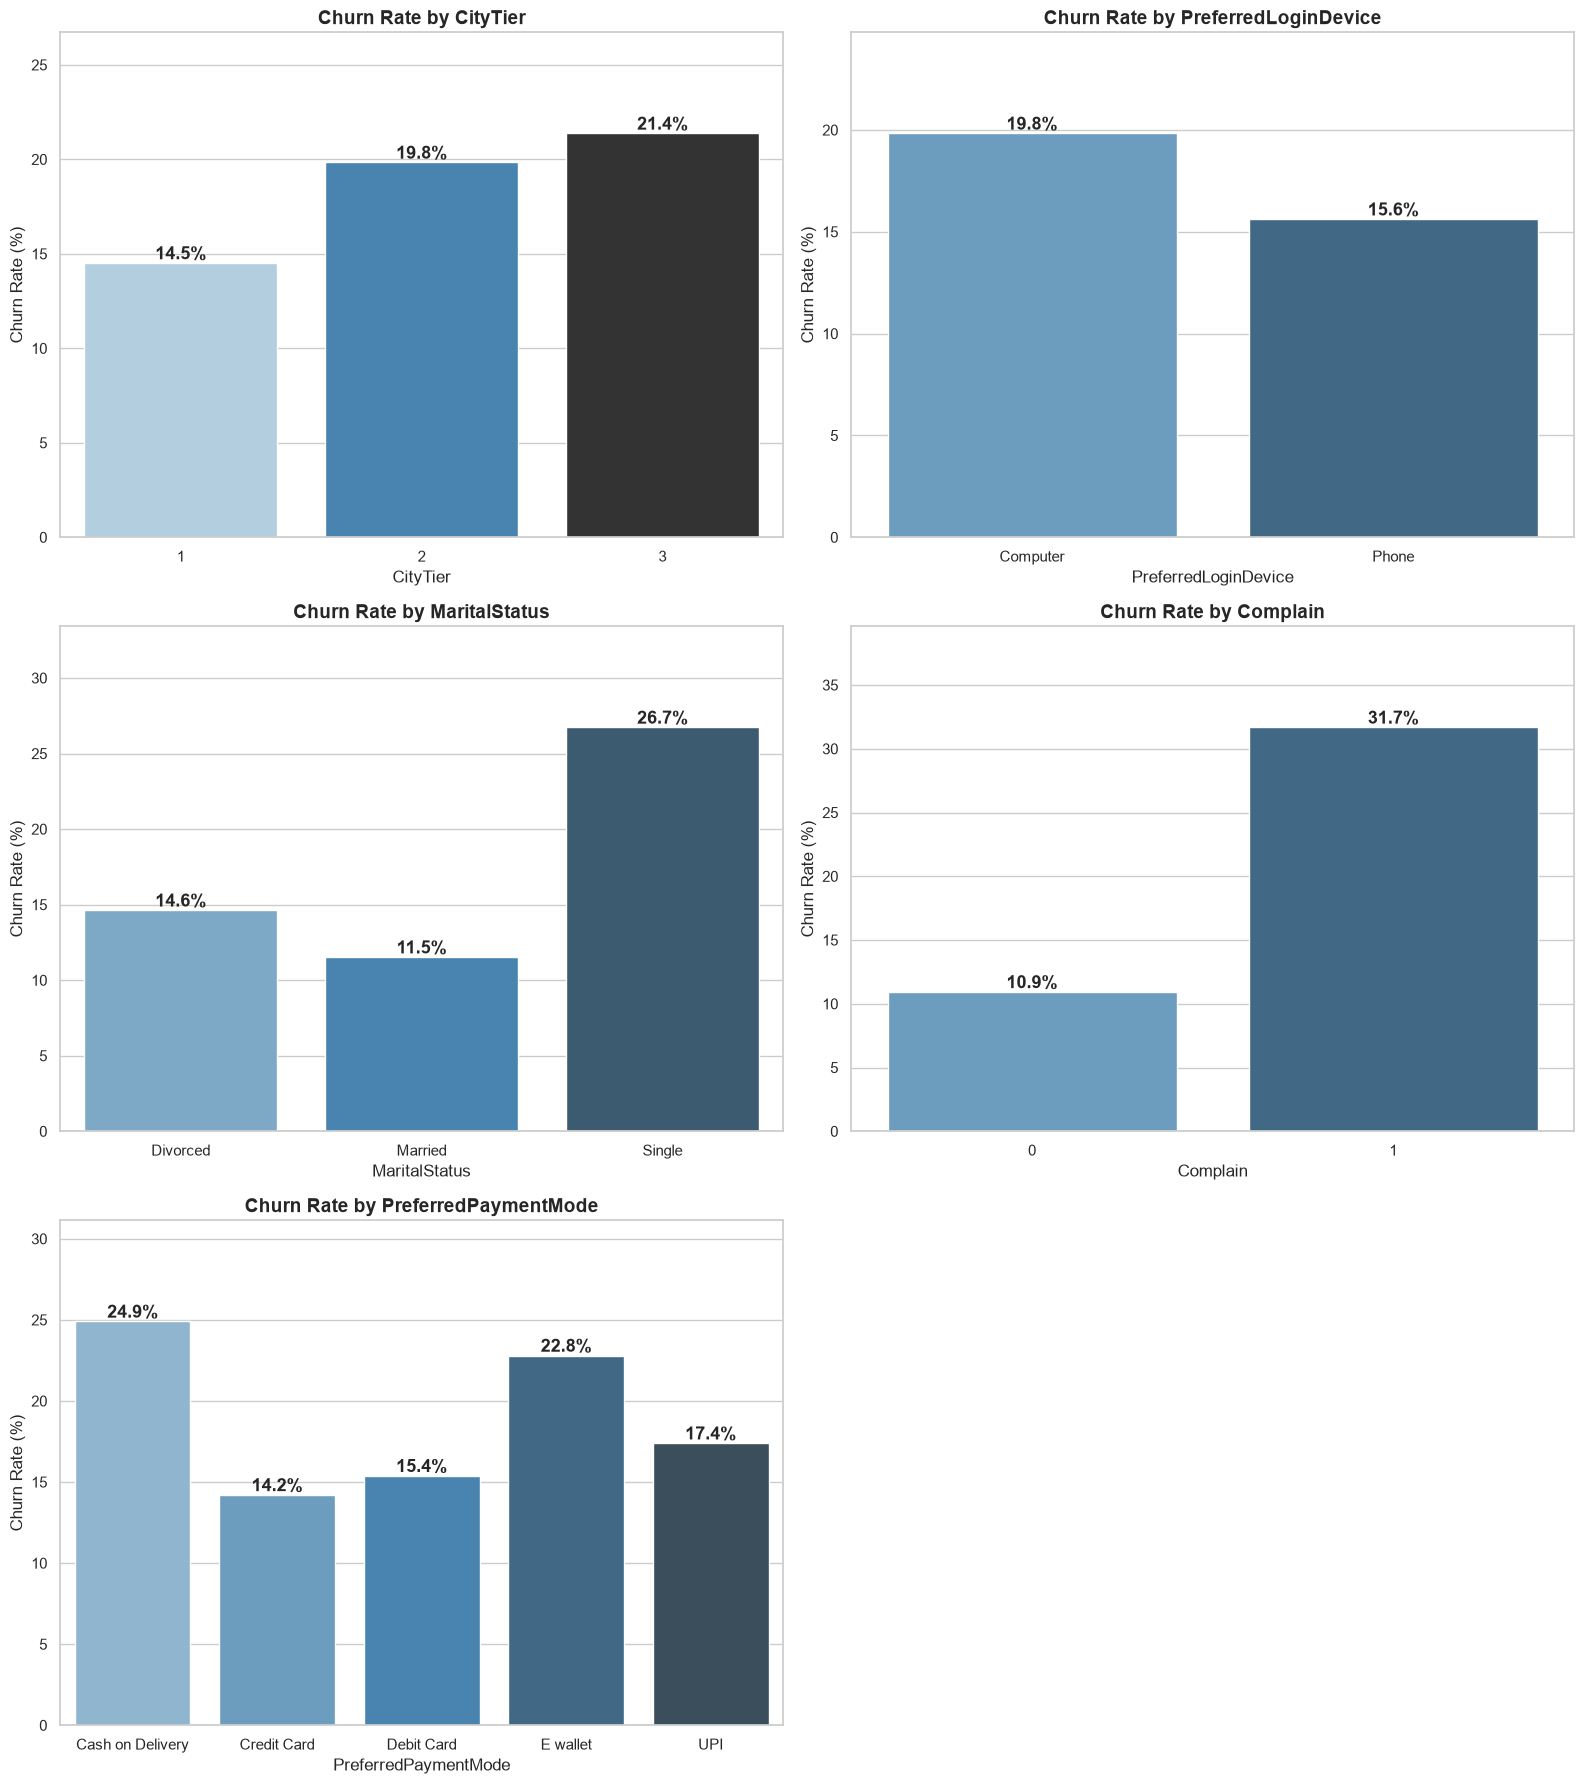

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(target_cols):
    data = df.groupby(col)["Churn"].mean().reset_index()
    data["Churned_Pct"] = data["Churn"] * 100
    print(data["Churned_Pct"].head(5))
    
    ax = axes[idx]
    sns.barplot(
        data=data,
        x=col,
        y="Churned_Pct",
        ax=ax,
        palette="Blues_d",
        hue=col,
        legend=False
    )  
    
    ax.set_title(f"Churn Rate by {col}", fontsize=14, fontweight="bold")  
    ax.set_ylabel(f"Churn Rate (%)", fontsize=12)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylim(0, max(data["Churned_Pct"]) * 1.25)
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )
        
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Correlation heatmap for numeric features.**

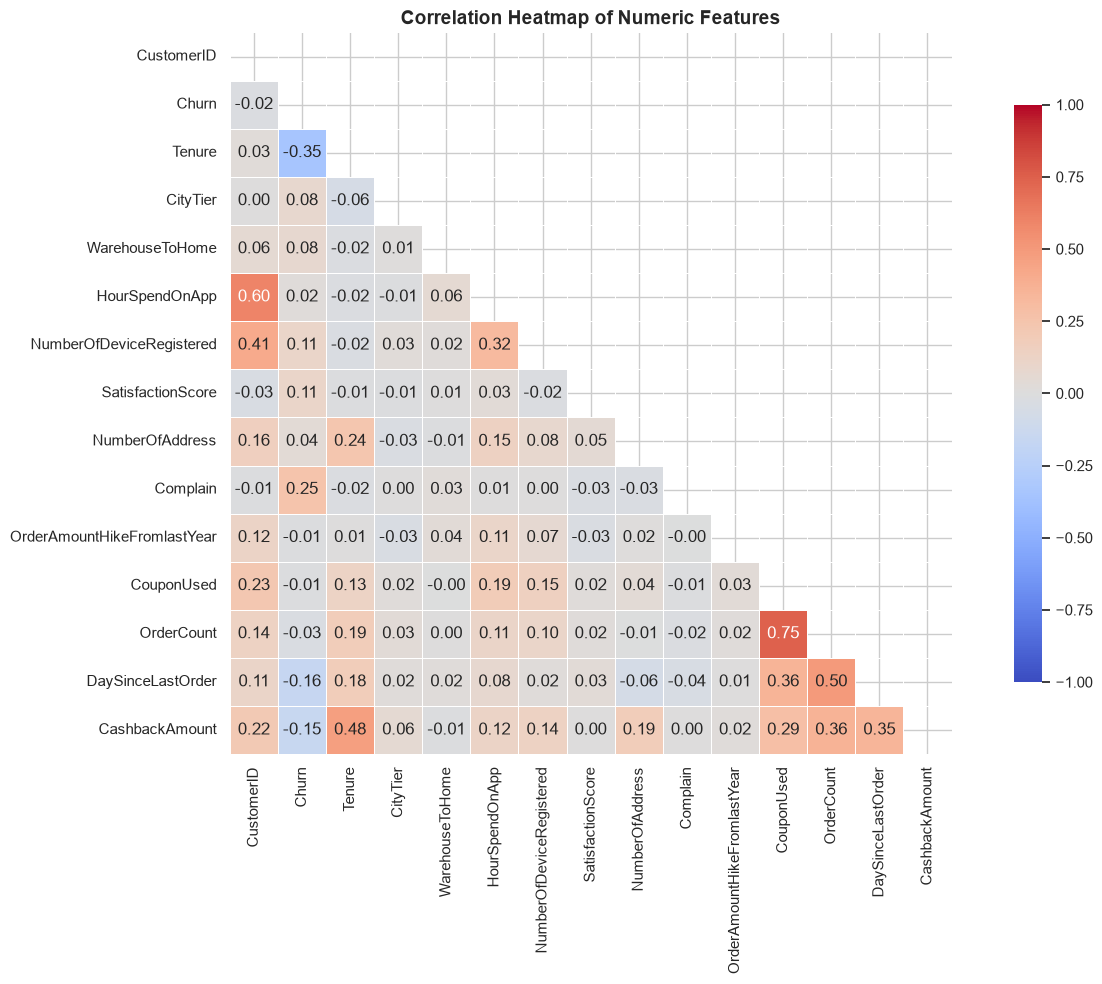

In [41]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    data=corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**My findings:**

1- The single customers are more have the most churn rate by marital status with 26.7% i think they need to engage them more in the ecommerce site

2- Customers that did complain are likely to churn from the site with as the chart show that complained customer have churn rate of 31.7% vs 10.9% churn rate for customers that did't complain 

3- The mean Tenure for customers is 10 month 